<a href="https://colab.research.google.com/github/lcn781/M_13_REGRESSAO_II/blob/main/Mod13_Tarefa_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EBAC - Regressão II - regressão múltipla

## Tarefa I

#### Previsão de renda

Vamos trabalhar com a base 'previsao_de_renda.csv', que é a base do seu próximo projeto. Vamos usar os recursos que vimos até aqui nesta base.

|variavel|descrição|
|-|-|
|data_ref                | Data de referência de coleta das variáveis |
|index                   | Código de identificação do cliente|
|sexo                    | Sexo do cliente|
|posse_de_veiculo        | Indica se o cliente possui veículo|
|posse_de_imovel         | Indica se o cliente possui imóvel|
|qtd_filhos              | Quantidade de filhos do cliente|
|tipo_renda              | Tipo de renda do cliente|
|educacao                | Grau de instrução do cliente|
|estado_civil            | Estado civil do cliente|
|tipo_residencia         | Tipo de residência do cliente (própria, alugada etc)|
|idade                   | Idade do cliente|
|tempo_emprego           | Tempo no emprego atual|
|qt_pessoas_residencia   | Quantidade de pessoas que moram na residência|
|renda                   | Renda em reais|

In [1]:
from inspect import ismemberdescriptor
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier

from scipy.stats import ks_2samp
import statsmodels.formula.api as smf
import statsmodels.api as sm
import patsy

%matplotlib inline

In [2]:
df = pd.read_csv('previsao_de_renda.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             15000 non-null  int64  
 1   data_ref               15000 non-null  object 
 2   id_cliente             15000 non-null  int64  
 3   sexo                   15000 non-null  object 
 4   posse_de_veiculo       15000 non-null  bool   
 5   posse_de_imovel        15000 non-null  bool   
 6   qtd_filhos             15000 non-null  int64  
 7   tipo_renda             15000 non-null  object 
 8   educacao               15000 non-null  object 
 9   estado_civil           15000 non-null  object 
 10  tipo_residencia        15000 non-null  object 
 11  idade                  15000 non-null  int64  
 12  tempo_emprego          12427 non-null  float64
 13  qt_pessoas_residencia  15000 non-null  float64
 14  renda                  15000 non-null  float64
dtypes:

In [4]:
print(df['tempo_emprego'].isnull().sum())

2573


In [5]:
# Impute missing values in 'tempo_emprego' with the median
median_tempo_emprego = df['tempo_emprego'].median()
df['tempo_emprego'].fillna(median_tempo_emprego, inplace=True)

# Verify that there are no more missing values
print(f"Missing values in 'tempo_emprego' after imputation: {df['tempo_emprego'].isnull().sum()}")

Missing values in 'tempo_emprego' after imputation: 0


/tmp/ipykernel_2023/2088007223.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['tempo_emprego'].fillna(median_tempo_emprego, inplace=True)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             15000 non-null  int64  
 1   data_ref               15000 non-null  object 
 2   id_cliente             15000 non-null  int64  
 3   sexo                   15000 non-null  object 
 4   posse_de_veiculo       15000 non-null  bool   
 5   posse_de_imovel        15000 non-null  bool   
 6   qtd_filhos             15000 non-null  int64  
 7   tipo_renda             15000 non-null  object 
 8   educacao               15000 non-null  object 
 9   estado_civil           15000 non-null  object 
 10  tipo_residencia        15000 non-null  object 
 11  idade                  15000 non-null  int64  
 12  tempo_emprego          15000 non-null  float64
 13  qt_pessoas_residencia  15000 non-null  float64
 14  renda                  15000 non-null  float64
dtypes:

1. Ajuste um modelo para prever log(renda) considerando todas as covariáveis disponíveis.
    - Utilizando os recursos do Patsy, coloque as variáveis qualitativas como *dummies*.
    - Mantenha sempre a categoria mais frequente como casela de referência
    - Avalie os parâmetros e veja se parecem fazer sentido prático.

2. Remova a variável menos significante e analise:
    - Observe os indicadores que vimos, e avalie se o modelo melhorou ou piorou na sua opinião.
    - Observe os parâmetros e veja se algum se alterou muito.

3. Siga removendo as variáveis menos significantes, sempre que o *p-value* for menor que 5%. Compare o modelo final com o inicial. Observe os indicadores e conclua se o modelo parece melhor.
    

In [14]:
# 1
# Ajuste um modelo para prever log(renda) considerando todas as covariáveis disponíveis.

  #   Utilizando os recursos do Patsy, coloque as variáveis qualitativas como dummies.
  #   Mantenha sempre a categoria mais frequente como casela de referência
  #   Avalie os parâmetros e veja se parecem fazer sentido prático.

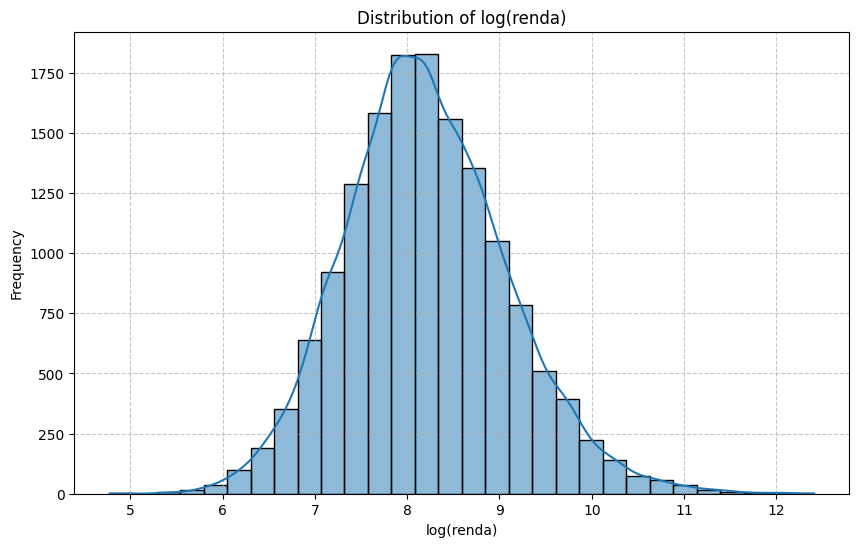

In [7]:
# Calculate log(renda) and add it as a new column
df['log_renda'] = np.log(df['renda'])

# Visualize the distribution of log_renda
plt.figure(figsize=(10, 6))
sns.histplot(df['log_renda'], kde=True, bins=30)
plt.title('Distribution of log(renda)')
plt.xlabel('log(renda)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [8]:
# Identify categorical columns (excluding 'data_ref' as it's not directly used in the model for now)
categorical_cols = ['sexo', 'posse_de_veiculo', 'posse_de_imovel', 'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']

# Determine the most frequent category for each categorical column
reference_categories = {}
for col in categorical_cols:
    reference_categories[col] = df[col].mode()[0]

print("Most frequent categories to be used as reference:")
for col, ref in reference_categories.items():
    print(f"  {col}: {ref}")

Most frequent categories to be used as reference:
  sexo: F
  posse_de_veiculo: False
  posse_de_imovel: True
  tipo_renda: Assalariado
  educacao: Secundário
  estado_civil: Casado
  tipo_residencia: Casa


In [9]:
# Construct the Patsy formula dynamically
formula_parts = []

# Add numerical variables
numerical_cols = ['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia']
formula_parts.extend(numerical_cols)

# Add categorical variables using C() for dummy encoding with the most frequent as reference
for col in categorical_cols:
    reference_value = reference_categories[col]
    if df[col].dtype == 'bool':
        # For boolean columns, pass the boolean value directly to Treatment
        # using .capitalize() to get 'True' or 'False' as string without quotes around the value in Treatment()
        formula_parts.append(f"C({col}, Treatment({str(reference_value).capitalize()}))")
    else:
        # For other categorical columns (objects/strings), pass the string value with quotes
        formula_parts.append(f"C({col}, Treatment('{reference_value}'))")

# Join all parts to create the full formula string
formula = 'log_renda ~ ' + ' + '.join(formula_parts)

print(f"Generated Formula: {formula}")

# Fit the OLS model
model = smf.ols(formula, data=df).fit()

# Print the model summary
print(model.summary())

Generated Formula: log_renda ~ qtd_filhos + idade + tempo_emprego + qt_pessoas_residencia + C(sexo, Treatment('F')) + C(posse_de_veiculo, Treatment(False)) + C(posse_de_imovel, Treatment(True)) + C(tipo_renda, Treatment('Assalariado')) + C(educacao, Treatment('Secundário')) + C(estado_civil, Treatment('Casado')) + C(tipo_residencia, Treatment('Casa'))
                            OLS Regression Results                            
Dep. Variable:              log_renda   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.347
Method:                 Least Squares   F-statistic:                     333.6
Date:                Mon, 13 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:59:45   Log-Likelihood:                -16213.
No. Observations:               15000   AIC:                         3.248e+04
Df Residuals:                   14975   BIC:                         3.267e+04
Df Model:     

In [ ]:
# 2
#Remova a variável menos significante e analise:

  #   Observe os indicadores que vimos, e avalie se o modelo melhorou ou piorou na sua opinião.
  #   Observe os parâmetros e veja se algum se alterou muito.

### Modelo 2: Removendo `tipo_residencia`

Baseado nos p-values do modelo, `tipo_residencia` parece ser a variável menos significante, já que todas suas categorias individuais apresentam um alto p-value.

In [10]:
# Remove 'tipo_residencia' from the list of categorical columns for the new formula
categorical_cols_model_2 = [col for col in categorical_cols if col != 'tipo_residencia']

# Construct the Patsy formula dynamically for Model 2
formula_parts_model_2 = []
formula_parts_model_2.extend(numerical_cols)

for col in categorical_cols_model_2:
    reference_value = reference_categories[col]
    if df[col].dtype == 'bool':
        formula_parts_model_2.append(f"C({col}, Treatment({str(reference_value).capitalize()}))")
    else:
        formula_parts_model_2.append(f"C({col}, Treatment('{reference_value}'))")

formula_model_2 = 'log_renda ~ ' + ' + '.join(formula_parts_model_2)

print(f"Generated Formula for Model 2: {formula_model_2}")

# Fit the OLS model
model_2 = smf.ols(formula_model_2, data=df).fit()

# Print the model summary
print(model_2.summary())

Generated Formula for Model 2: log_renda ~ qtd_filhos + idade + tempo_emprego + qt_pessoas_residencia + C(sexo, Treatment('F')) + C(posse_de_veiculo, Treatment(False)) + C(posse_de_imovel, Treatment(True)) + C(tipo_renda, Treatment('Assalariado')) + C(educacao, Treatment('Secundário')) + C(estado_civil, Treatment('Casado'))
                            OLS Regression Results                            
Dep. Variable:              log_renda   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.347
Method:                 Least Squares   F-statistic:                     421.2
Date:                Mon, 13 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:59:50   Log-Likelihood:                -16214.
No. Observations:               15000   AIC:                         3.247e+04
Df Residuals:                   14980   BIC:                         3.262e+04
Df Model:                          19     

###Observando e Comparando

- R2 e R2 Ajustado:
Ambos os modelos apresentaram valores quase idênticos, mostrando que a remoção da variável `tipo_residencia` não reduziu significativamente a capacidade de explicação do modelo. Isso era esperado, uma vez que a variável não era significativa.

- AIC e BIC:
O Modelo 2 apresentou um valor um pouco menor de AIC e BIC, sugerindo um melhor ajuste do modelo com menos parâmentros, que é um resultado positivo pra simplificação do modelo.

- F-statistic:
O Modelo 2 teve um valor maior, indicando que ele ainda é estatisticamente significativo, e potencialmente explica mais a variância relativo a sua complexidade, por ter menos preditores



###CONCLUSÃO:
Remover a variável `tipo_residencia` resultou num modelo mais econômico, sem sacrificar capacidade de expicação, o que é um bom passo rumo ao melhoramento do modelo.

In [ ]:
# 3
# Siga removendo as variáveis menos significantes, sempre que o p-value for menor que 5%.
# Compare o modelo final com o inicial.
# Observe os indicadores e conclua se o modelo parece melhor.

### Model 3: Removing `tipo_renda`

Following the iterative removal process, we will now remove `tipo_renda` from the model formula and refit the model.

In [11]:
# Remove 'tipo_renda' from the list of categorical columns for the new formula
categorical_cols_model_3 = [col for col in categorical_cols_model_2 if col != 'tipo_renda']

# Construct the Patsy formula dynamically for Model 3
formula_parts_model_3 = []
formula_parts_model_3.extend(numerical_cols)

for col in categorical_cols_model_3:
    reference_value = reference_categories[col]
    if df[col].dtype == 'bool':
        formula_parts_model_3.append(f"C({col}, Treatment({str(reference_value).capitalize()}))")
    else:
        formula_parts_model_3.append(f"C({col}, Treatment('{reference_value}'))")

formula_model_3 = 'log_renda ~ ' + ' + '.join(formula_parts_model_3)

print(f"Generated Formula for Model 3: {formula_model_3}")

# Fit the OLS model
model_3 = smf.ols(formula_model_3, data=df).fit()

# Print the model summary
print(model_3.summary())

Generated Formula for Model 3: log_renda ~ qtd_filhos + idade + tempo_emprego + qt_pessoas_residencia + C(sexo, Treatment('F')) + C(posse_de_veiculo, Treatment(False)) + C(posse_de_imovel, Treatment(True)) + C(educacao, Treatment('Secundário')) + C(estado_civil, Treatment('Casado'))
                            OLS Regression Results                            
Dep. Variable:              log_renda   R-squared:                       0.342
Model:                            OLS   Adj. R-squared:                  0.341
Method:                 Least Squares   F-statistic:                     518.2
Date:                Mon, 13 Jul 2026   Prob (F-statistic):               0.00
Time:                        16:00:06   Log-Likelihood:                -16290.
No. Observations:               15000   AIC:                         3.261e+04
Df Residuals:                   14984   BIC:                         3.273e+04
Df Model:                          15                                         
Covar

### Model 4: Removing `educacao`

Continuing the iterative process, we will now remove the `educacao` variable from the model formula and refit the model.

In [12]:
# Remove 'educacao' from the list of categorical columns for the new formula
categorical_cols_model_4 = [col for col in categorical_cols_model_3 if col != 'educacao']

# Construct the Patsy formula dynamically for Model 4
formula_parts_model_4 = []
formula_parts_model_4.extend(numerical_cols)

for col in categorical_cols_model_4:
    reference_value = reference_categories[col]
    if df[col].dtype == 'bool':
        formula_parts_model_4.append(f"C({col}, Treatment({str(reference_value).capitalize()}))")
    else:
        formula_parts_model_4.append(f"C({col}, Treatment('{reference_value}'))")

formula_model_4 = 'log_renda ~ ' + ' + '.join(formula_parts_model_4)

print(f"Generated Formula for Model 4: {formula_model_4}")

# Fit the OLS model
model_4 = smf.ols(formula_model_4, data=df).fit()

# Print the model summary
print(model_4.summary())

Generated Formula for Model 4: log_renda ~ qtd_filhos + idade + tempo_emprego + qt_pessoas_residencia + C(sexo, Treatment('F')) + C(posse_de_veiculo, Treatment(False)) + C(posse_de_imovel, Treatment(True)) + C(estado_civil, Treatment('Casado'))
                            OLS Regression Results                            
Dep. Variable:              log_renda   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     690.9
Date:                Mon, 13 Jul 2026   Prob (F-statistic):               0.00
Time:                        16:03:24   Log-Likelihood:                -16348.
No. Observations:               15000   AIC:                         3.272e+04
Df Residuals:                   14988   BIC:                         3.281e+04
Df Model:                          11                                         
Covariance Type:            nonrobust       

### Model 5: Removing `estado_civil`

Continuing the iterative process, we will now remove the `estado_civil` variable from the model formula and refit the model.

In [13]:
# Remove 'estado_civil' from the list of categorical columns for the new formula
categorical_cols_model_5 = [col for col in categorical_cols_model_4 if col != 'estado_civil']

# Construct the Patsy formula dynamically for Model 5
formula_parts_model_5 = []
formula_parts_model_5.extend(numerical_cols)

for col in categorical_cols_model_5:
    reference_value = reference_categories[col]
    if df[col].dtype == 'bool':
        formula_parts_model_5.append(f"C({col}, Treatment({str(reference_value).capitalize()}))")
    else:
        formula_parts_model_5.append(f"C({col}, Treatment('{reference_value}'))")

formula_model_5 = 'log_renda ~ ' + ' + '.join(formula_parts_model_5)

print(f"Generated Formula for Model 5: {formula_model_5}")

# Fit the OLS model
model_5 = smf.ols(formula_model_5, data=df).fit()

# Print the model summary
print(model_5.summary())

Generated Formula for Model 5: log_renda ~ qtd_filhos + idade + tempo_emprego + qt_pessoas_residencia + C(sexo, Treatment('F')) + C(posse_de_veiculo, Treatment(False)) + C(posse_de_imovel, Treatment(True))
                            OLS Regression Results                            
Dep. Variable:              log_renda   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     1084.
Date:                Mon, 13 Jul 2026   Prob (F-statistic):               0.00
Time:                        16:22:38   Log-Likelihood:                -16354.
No. Observations:               15000   AIC:                         3.272e+04
Df Residuals:                   14992   BIC:                         3.278e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
    

### Model 6: Removing `qt_pessoas_residencia`

Continuing the iterative process, we will now remove the `qt_pessoas_residencia` variable from the model formula and refit the model.

In [14]:
# Remove 'qt_pessoas_residencia' from the list of numerical columns for the new formula
numerical_cols_model_6 = [col for col in numerical_cols if col != 'qt_pessoas_residencia']

# The categorical_cols_model_5 list already contains the relevant categorical columns

# Construct the Patsy formula dynamically for Model 6
formula_parts_model_6 = []
formula_parts_model_6.extend(numerical_cols_model_6)

for col in categorical_cols_model_5:
    reference_value = reference_categories[col]
    if df[col].dtype == 'bool':
        formula_parts_model_6.append(f"C({col}, Treatment({str(reference_value).capitalize()}))")
    else:
        formula_parts_model_6.append(f"C({col}, Treatment('{reference_value}'))")

formula_model_6 = 'log_renda ~ ' + ' + '.join(formula_parts_model_6)

print(f"Generated Formula for Model 6: {formula_model_6}")

# Fit the OLS model
model_6 = smf.ols(formula_model_6, data=df).fit()

# Print the model summary
print(model_6.summary())

Generated Formula for Model 6: log_renda ~ qtd_filhos + idade + tempo_emprego + C(sexo, Treatment('F')) + C(posse_de_veiculo, Treatment(False)) + C(posse_de_imovel, Treatment(True))
                            OLS Regression Results                            
Dep. Variable:              log_renda   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     1264.
Date:                Mon, 13 Jul 2026   Prob (F-statistic):               0.00
Time:                        16:24:36   Log-Likelihood:                -16354.
No. Observations:               15000   AIC:                         3.272e+04
Df Residuals:                   14993   BIC:                         3.277e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            

### Residual Analysis for Model 6

To validate the assumptions of the linear regression model, we will perform residual analysis on `model_6`.

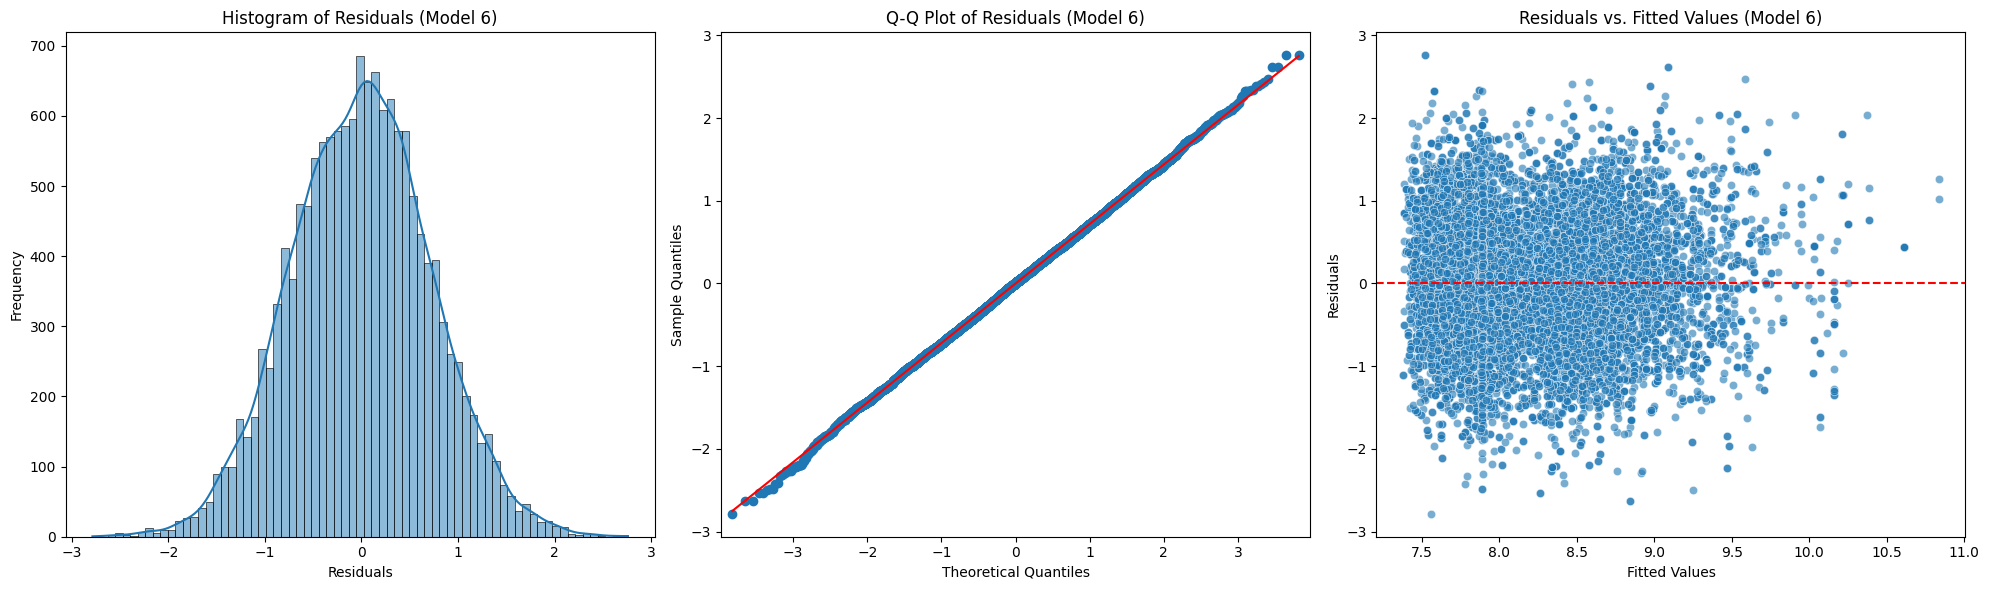

In [15]:
# Calculate fitted values and residuals
fitted_values_6 = model_6.fittedvalues
residuals_6 = model_6.resid

# Plotting residuals
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Histogram of residuals
sns.histplot(residuals_6, kde=True, ax=axes[0])
axes[0].set_title('Histogram of Residuals (Model 6)')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')

# Q-Q plot of residuals for normality check
sm.qqplot(residuals_6, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot of Residuals (Model 6)')

# Residuals vs. Fitted Values plot for homoscedasticity and linearity
sns.scatterplot(x=fitted_values_6, y=residuals_6, ax=axes[2], alpha=0.6)
axes[2].set_title('Residuals vs. Fitted Values (Model 6)')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Residuals')
axes[2].axhline(y=0, color='r', linestyle='--')

plt.tight_layout()
plt.show()

###Observações e Comparações

- COMPLEXIDADE

Removemos as variáveis `tipo_residencia`, `tipo_renda`, `estado_civil`, e `qt_pessoas_residencia`.

- R2/R2 AJUSTADO

O valor de R2 caiu de 0.348 para 0.336. Apesar dessa queda na explicação da variância, é uma troca que compensa pela simplificação substancial do modelo

- AIC / BIC

AIC aumentou de 32480 pra 32720, e o BIC foi de 3260 para 32770.
Inicialmente, quando removemos `tipo_residencia`, essas métricas melhoraram. Nas remoções seguintes, elas voltaram a aumentar. Isso sugere que, apesar de termos removidos variáveis insignificantes de acordo com o p-value, algumas dessas remoções levaram a um equilíbrio pior entre o ajuste e a complexidade do modelo. Isso indica que as variáveis `tipo_renda`, `educação` e `estado_civil`, tinham alguma informação útil, mesmo que algumas categorias específicas não eram estatisticamente significantes.

- F-statistic:

Apresentou um aumento dramático, de 336 para 1264. Isso indica que o modelo final é altamente significativo, e que as variáveis remanescentes são um forte indicador preditivo.

- Análise de Resíduos

O histograma apresenta a forma de sino bem centrada ao redor de zero, sugerindo que os resíduos estão normalmente distruibuídos.

O Q-Plot seguem a linha de referência de 45o, corroborando a suposição de normalidade nos resíduos.

O ScatterPlot mostra uma distribuição bem aleatória de resíduos ao redor de zero, sem nenhum padrão ou tendência. Isso sugere que a presunção de linearidade e homocedasticidade são satisfatórias, indicando um ajuste razoavelmente bom.

###CONCLUSÃO

O modelo 6 é muito mais econômico que o modelo inicial. Apesar de apresentar uma queda no valor de R2, e um aumento de AIC/BIC durante o processo, a estabilidade dessas métricas e o aumento do F-statistic sugerem que chegamos em um modelo mais simples e mais eficiente, sem sacrificar muito a capacidade preditiva. As variáveis remanescentes são todas estatisticamente significantes, e provavelmente bons preditivos pra variável `log_renda` nesse conjunto de dados.

